## 1.Problem Tanımı
* Hangi ülkeler en çok satış yapıyor?
* Satışlar zaman içinde nasıl değişiyor?
* En çok satan ürün kategorisi hangisi ve neden?

## 2. Veriyi Yükle

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("sales_data_sample.csv", encoding="latin-1")

## 3. EDA

In [2]:
df.shape

(2823, 25)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [4]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [5]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [6]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


## 4. Veri Temizleme

In [7]:
# ORDERDATE sütununu datetime'a çevirme.
df['ORDERDATE'] = pd.to_datetime(df["ORDERDATE"])

In [8]:
df.drop(columns=["PHONE", "ADDRESSLINE1", "ADDRESSLINE2", "CONTACTLASTNAME", "CONTACTFIRSTNAME", "ORDERNUMBER", "QTR_ID", "MONTH_ID", "YEAR_ID"], inplace=True)

In [9]:
df.drop(columns=["POSTALCODE", "CUSTOMERNAME"], inplace=True)

In [10]:
df.drop(columns=["STATE", "TERRITORY"], inplace=True)

In [11]:
df.drop(columns=["MSRP", "PRODUCTCODE", "ORDERLINENUMBER"], inplace=True)

In [12]:
df.columns

Index(['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'ORDERDATE', 'STATUS',
       'PRODUCTLINE', 'CITY', 'COUNTRY', 'DEALSIZE'],
      dtype='object')

In [13]:
df.isnull().sum()

QUANTITYORDERED    0
PRICEEACH          0
SALES              0
ORDERDATE          0
STATUS             0
PRODUCTLINE        0
CITY               0
COUNTRY            0
DEALSIZE           0
dtype: int64

In [14]:
df["YEAR"]=df["ORDERDATE"].dt.year
df["MONTH"]=df["ORDERDATE"].dt.month

In [15]:
df.head()

,QUANTITYORDERED,PRICEEACH,SALES,ORDERDATE,STATUS,PRODUCTLINE,CITY,COUNTRY,DEALSIZE,YEAR,MONTH
0,30,95.70,2871.00,2003-02-24,Shipped,Motorcycles,NYC,USA,Small,2003,2
1,34,81.35,2765.90,2003-05-07,Shipped,Motorcycles,Reims,France,Small,2003,5
2,41,94.74,3884.34,2003-07-01,Shipped,Motorcycles,Paris,France,Medium,2003,7
3,45,83.26,3746.70,2003-08-25,Shipped,Motorcycles,Pasadena,USA,Medium,2003,8
4,49,100.00,5205.27,2003-10-10,Shipped,Motorcycles,San Francisco,USA,Medium,2003,10


## 5. Analiz

Text(0.5, 1.0, 'Ülkelerin Toplam Satışları')

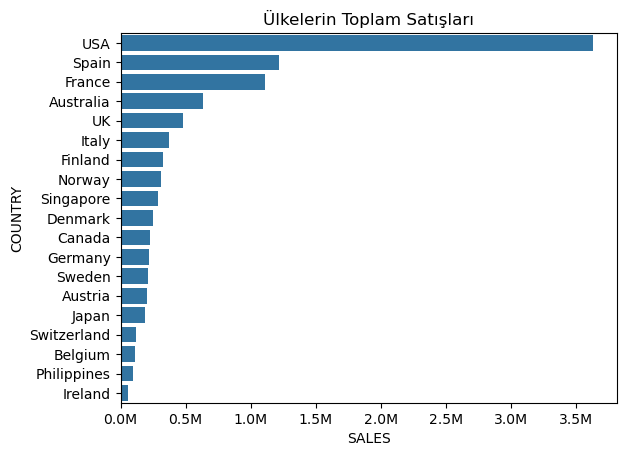

In [16]:
## AMAÇ :"Hangi ülkeler en çok satış yapıyor?"
## NEDEN : Bu grafiği ülkeler arasındaki satış miktarlarını incelemek amacıyla çiziyorum.
countries_by_sales=df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False)
ax=sns.barplot(data=countries_by_sales, orient="h")
from matplotlib.ticker import FuncFormatter
def format_func(value, pos):
    return f"{value/1_000_000:.1f}M"
ax.xaxis.set_major_formatter(FuncFormatter(format_func))
plt.title("Ülkelerin Toplam Satışları")
## Bu grafik Ülkelerin Toplam Satışları incelendiğinde Amerika Birleşik Devletleri'nin diğer ülkelerden çok daha fazla hasılat elde ettiğini gösteriyor.

Bu grafik Amerika Birleşik devletlerinin pazardaki payının % 36 civarı olduğunu gösterirken burada firmalar arasında daha yüksek rekabet olacağını
varsayarsak bu da şirketin pazarlama bütçelerinde artışa gitmesini gerektirebilir.

In [17]:
## AMAÇ :"Zaman bazlı satış trendi"
## NEDEN : Bu grafiği zaman periyotları arasında satış miktarları yönünden ne gibi farklılıklar olduğunu saptamak için çiziyorum.
df["PERIOD"]=df["ORDERDATE"].dt.to_period("M")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28],
 [Text(0, 0, '2003-01'),
  Text(1, 0, '2003-02'),
  Text(2, 0, '2003-03'),
  Text(3, 0, '2003-04'),
  Text(4, 0, '2003-05'),
  Text(5, 0, '2003-06'),
  Text(6, 0, '2003-07'),
  Text(7, 0, '2003-08'),
  Text(8, 0, '2003-09'),
  Text(9, 0, '2003-10'),
  Text(10, 0, '2003-11'),
  Text(11, 0, '2003-12'),
  Text(12, 0, '2004-01'),
  Text(13, 0, '2004-02'),
  Text(14, 0, '2004-03'),
  Text(15, 0, '2004-04'),
  Text(16, 0, '2004-05'),
  Text(17, 0, '2004-06'),
  Text(18, 0, '2004-07'),
  Text(19, 0, '2004-08'),
  Text(20, 0, '2004-09'),
  Text(21, 0, '2004-10'),
  Text(22, 0, '2004-11'),
  Text(23, 0, '2004-12'),
  Text(24, 0, '2005-01'),
  Text(25, 0, '2005-02'),
  Text(26, 0, '2005-03'),
  Text(27, 0, '2005-04'),
  Text(28, 0, '2005-05')])

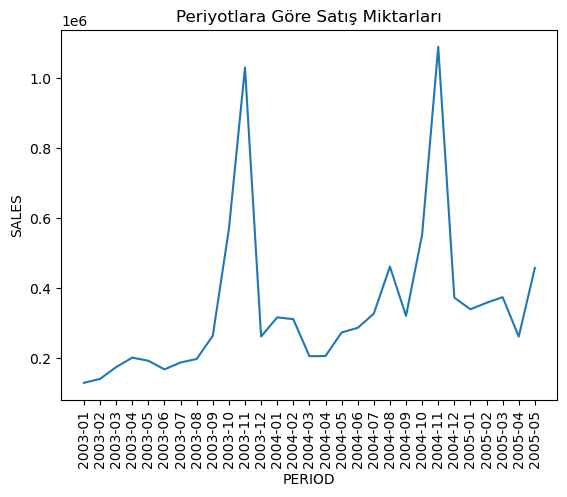

In [18]:
months_sales=pd.DataFrame(df.groupby("PERIOD")["SALES"].sum())
months_sales.index=months_sales.index.astype(str)
sns.lineplot(data=months_sales, x=months_sales.index, y=months_sales["SALES"])
plt.title("Periyotlara Göre Satış Miktarları")
plt.xticks(rotation=90)

Yukarıdaki grafiği incelediğimizde en yüksek satışların 2003 Yılının Kasım ayında ve ardından 2004 Yılının Kasım ayında olduğunu görüyoruz. Her iki en büyük satış miktarınının sebebinin Black - Friday olduğu düşünülebilir. 2005 yılının bütün verisi olmadığından yıllar arası karşılaştırma yapmamız sağlıklı olmaz ancak Kasım zirvesinin her yıl tekrar etmesi nedeniyle şirketimiz Kasım ayına girerken elindeki stok miktarını önemli derecede artırırsa çok yüksek kar marjı yakalayabilir.

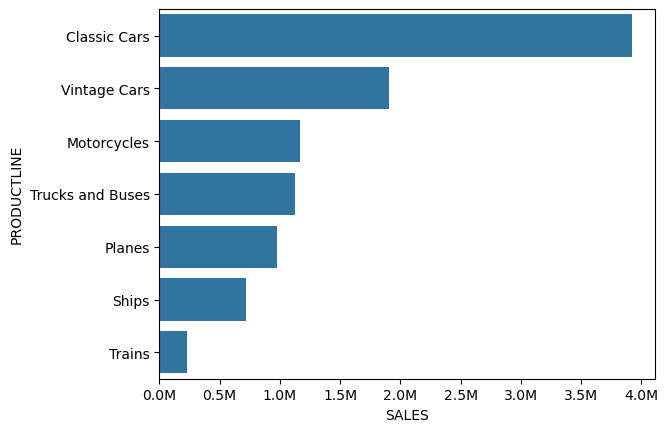

In [19]:
## AMAÇ :"Ürün kategorilerine göre satış"
## NEDEN : Bu grafiği ürün kategorileri arasındaki satış miktarları farklılıklarını incelemek  ve yorumlamak amacıyla çiziyorum.
sales_products=df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)
ax=sns.barplot(data=sales_products, orient="h")
from matplotlib.ticker import FuncFormatter
def format_function(value, pos):
  return f"{value/1_000_000:.1f}M"  
ax.xaxis.set_major_formatter(FuncFormatter(format_function))

Yukarıdaki grafiği incelediğimizde Tren satışlarından gelen gelirin Klasik arabalardan gelen gelire göre oranlamasının yaklaşık %5 olduğunu görüyoruz. Bu doğrultuda şirketimiz Tren üretimine harcadığı parayı Klasik Araba sektörüne yatırarak daha çok araba üretip daha ucuza araba satışı sağlayabilir. 

## 6. Sonuç

* Amerika birleşik devletlerinin en çok satış geliri elde eden ülke olduğu düşünüldüğünde, şirketimizin amerika pazarındaki ürünlerine diğer firmalarla rekabet edebilmesi açısından daha fazla pazarlama payı ayırması gerekebilir. Ek olarak yeni müşteriler çekebilmek adına ilk alımlarda belirli bir indirim yapılabilir.
* 2005 verisinin tamamına sahip olamasak bile En yüksek satış gelirimizi 2003 ve 2004 Kasım ayında elde ettiğimizden yola çıkarak, Her Kasım ayına girerken kapasite fazlası üretim yapmaya çalışarak daha yüksek kar elde edebiliriz.
* Klasik Arabaların satış gelirinden aldığı payı düşündüğümüzde, diğer firmalardan sıyrılabilmek adına bu üretim alanındaki yeniliklere daha fazla para harcayarak rakiplerimizin önüne geçebiliriz.